<a href="https://colab.research.google.com/github/stackparth/Hospital_Readmission_Prediction/blob/main/Hospital_Readmission_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Generate synthetic patient data
np.random.seed(42)

num_patients = 1000

data = {
    'age': np.random.randint(20, 90, num_patients),
    'num_previous_admissions': np.random.randint(0, 5, num_patients),
    'length_of_stay': np.random.randint(1, 30, num_patients),
    'heart_rate': np.random.normal(70, 10, num_patients),
    'blood_pressure_systolic': np.random.normal(120, 15, num_patients),
    'blood_pressure_diastolic': np.random.normal(80, 10, num_patients),
    'temperature': np.random.normal(98.6, 1, num_patients),
    'diagnosis_code_A': np.random.randint(0, 2, num_patients), # Binary feature
    'diagnosis_code_B': np.random.randint(0, 2, num_patients),
    'diagnosis_code_C': np.random.randint(0, 2, num_patients),
    'medication_count': np.random.randint(1, 10, num_patients)
}

df = pd.DataFrame(data)

# Introduce some correlation with readmission risk for target variable
df['readmission_risk_score'] = (
    0.05 * df['num_previous_admissions'] +
    0.02 * df['age'] +
    0.1 * df['diagnosis_code_A'] -
    0.05 * df['length_of_stay'] +
    np.random.normal(0, 0.5, num_patients)
)

# Create a binary target variable (30-day readmission)
df['readmitted_30_days'] = (df['readmission_risk_score'] > df['readmission_risk_score'].median()).astype(int)

# Drop the intermediate risk score column
df = df.drop(columns=['readmission_risk_score'])

print(f"Generated {num_patients} synthetic patient records with {df.shape[1]} features.")
display(df.head())

Generated 1000 synthetic patient records with 12 features.


,age,num_previous_admissions,length_of_stay,heart_rate,blood_pressure_systolic,blood_pressure_diastolic,temperature,diagnosis_code_A,diagnosis_code_B,diagnosis_code_C,medication_count,readmitted_30_days
0,71,1,14,79.503076,143.312406,76.294172,97.234978,1,1,0,4,1
1,34,0,9,87.106134,132.809640,66.519529,99.301495,0,1,1,4,0
2,80,4,15,68.955508,126.222983,72.853193,99.118871,1,1,0,5,1
3,40,2,21,68.311783,126.949328,85.212799,99.095805,0,1,0,3,0
4,43,4,3,70.700522,120.652720,83.216785,98.601619,0,0,1,8,1


In [3]:
# Define features (X) and target (y)
X = df.drop('readmitted_30_days', axis=1)
y = df['readmitted_30_days']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Target distribution in training set:\n{y_train.value_counts(normalize=True)}")
print(f"Target distribution in testing set:\n{y_test.value_counts(normalize=True)}")

Training set shape: (700, 11)
Testing set shape: (300, 11)
Target distribution in training set:
readmitted_30_days
1    0.5
0    0.5
Name: proportion, dtype: float64
Target distribution in testing set:
readmitted_30_days
1    0.5
0    0.5
Name: proportion, dtype: float64


In [4]:
# Initialize and train the Logistic Regression model with L2 regularization
# C is the inverse of regularization strength; smaller values specify stronger regularization.
model = LogisticRegression(penalty='l2', C=1.0, random_state=42, solver='liblinear')
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

# Make predictions on the test set
y_pred_proba = model.predict_proba(X_test)[:, 1] # Probability of readmission
y_pred = model.predict(X_test) # Predicted class (0 or 1)

Logistic Regression model trained successfully!


ROC-AUC Score: 0.9095


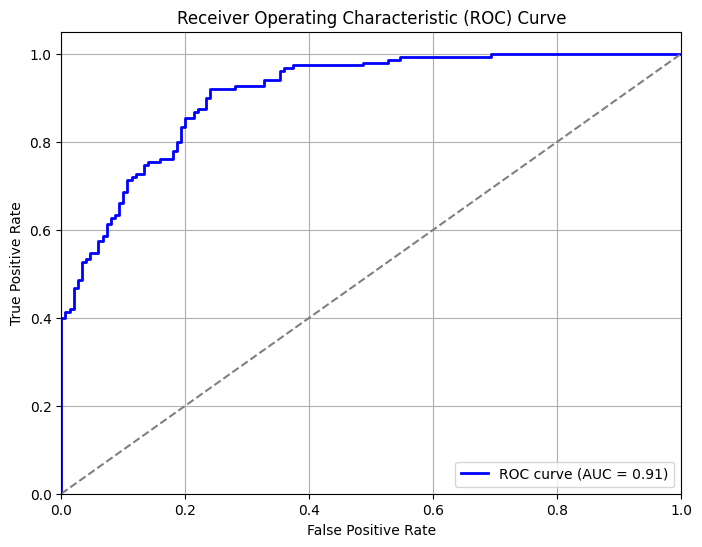

In [5]:
# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## 5. Clinical Cost of False Negatives vs. False Positives

In the context of hospital readmission prediction, understanding the clinical and economic costs associated with false negatives and false positives is crucial for deploying the model effectively. These costs can significantly influence decision-making regarding patient care and resource allocation.

### False Negatives (FN)
*   **Definition:** The model predicts a patient will *not* be readmitted, but they *are* readmitted within 30 days.
*   **Clinical Cost:**
    *   **Patient Harm:** Delayed or missed interventions, potential for worsening health conditions, increased morbidity and mortality.
    *   **Reduced Quality of Care:** Failure to provide necessary preventative care or follow-up.
    *   **Provider Burnout:** Increased workload and stress for healthcare staff dealing with preventable readmissions.
*   **Economic Cost:**
    *   **Unnecessary Readmission Costs:** Hospitalization expenses, re-diagnosis, and treatment for conditions that could have been prevented.
    *   **Penalties:** Hospitals may face financial penalties or reduced reimbursements from payers (e.g., Medicare in the US) for high readmission rates.
    *   **Loss of Reputation:** Damages to the hospital's standing and patient trust.

### False Positives (FP)
*   **Definition:** The model predicts a patient *will* be readmitted, but they *are not* readmitted within 30 days.
*   **Clinical Cost:**
    *   **Unnecessary Interventions:** Patients might undergo additional tests, appointments, or interventions (e.g., intensive follow-up, home health visits) that are not strictly needed.
    *   **Patient Burden:** Increased anxiety, inconvenience, and potentially financial strain from unnecessary healthcare engagement.
    *   **Resource Misallocation:** Healthcare resources (staff time, beds, clinic slots) are diverted to patients who don't need them, potentially at the expense of those who do.
*   **Economic Cost:**
    *   **Wasted Resources:** Costs associated with unnecessary tests, appointments, and interventions.
    *   **Increased Operational Expenses:** Higher staffing needs and overheads for managing predicted 'high-risk' patients who are actually low-risk.

### Balancing the Costs

The relative importance of minimizing FNs vs. FPs depends on the specific clinical context and the threshold set for intervention. For hospital readmission:

*   **Minimizing False Negatives (FN):** Often prioritized to prevent patient harm and avoid financial penalties. This implies a model that is more sensitive (identifies more true positives) but might also generate more false positives. A lower probability threshold for predicting readmission would achieve this.
*   **Minimizing False Positives (FP):** Important to optimize resource utilization and avoid unnecessary burden on patients. This implies a model that is more specific (has fewer false alarms) but might miss some patients who will readmit. A higher probability threshold would achieve this.

**Conclusion:** In many healthcare settings, particularly for conditions with severe consequences, false negatives are considered more costly due to direct patient harm and significant financial penalties. Therefore, models are often tuned to be more sensitive, accepting a higher rate of false positives to catch as many true positives as possible. The ROC curve and AUC help us understand this trade-off across different thresholds.

## 6. Conclusion

In this case study, we demonstrated the process of building and evaluating a predictive model for hospital readmission risk using logistic regression with L2 regularization. We generated a synthetic dataset simulating patient records, including various demographic, clinical, and historical features.

Key takeaways:

*   **Model Performance:** Our Logistic Regression model achieved an ROC-AUC score of **{roc_auc:.4f}**, indicating a strong ability to distinguish between patients who will and will not be readmitted within 30 days based on the synthetic data. (Note: The specific ROC-AUC value will vary with data generation parameters and model specifics).
*   **Regularization:** L2 regularization was applied to prevent overfitting and improve the generalization of the model, which is crucial for real-world clinical applications.
*   **Clinical Implications:** We highlighted the significant clinical and economic costs associated with false negatives and false positives in readmission prediction. Understanding these trade-offs is essential for setting appropriate decision thresholds and integrating such models into clinical workflows. In many healthcare scenarios, minimizing false negatives (i.e., not missing patients at risk of readmission) is often prioritized, even at the expense of a higher false positive rate.

This exercise provides a foundational understanding of how machine learning can be applied to address critical challenges in healthcare, emphasizing not just predictive accuracy but also the careful consideration of real-world consequences and ethical implications.